In [8]:
import numpy
import pandas

In [9]:
df = pandas.read_csv("data/releves_incidents.csv")
df.head()

,incident_id,date,time,operator_name,machine_id,severity,operator_badge,comment,shift,type_surchauffe,type_baisse_pression,type_vibration,type_bruit_mecanique,type_surconsommation,type_blocage_mecanique,type_alarme_capteur,type_arret_urgence,type_defaut_qualite
0,INC-000001,2025-06-01,05:00,Lucas Bernard,MACH-06,1,OP1002,chauffe anormale,nuit,1,0,0,0,0,0,0,0,0
1,INC-000002,2025-06-01,21:00,Hugo Thomas,MACH-15,1,OP1004,micro-fuite / baisse pression,apres-midi,0,1,0,0,0,0,0,0,0
2,INC-000003,2025-06-01,22:00,Lucas Bernard,MACH-12,2,OP1002,bruit mécanique anormal,nuit,0,0,0,1,0,0,0,0,0
3,INC-000004,2025-06-04,05:00,Lucas Bernard,MACH-10,1,OP1002,alarme capteur,nuit,0,0,0,0,0,0,1,0,0
4,INC-000005,2025-06-04,22:00,Chloé Robert,MACH-01,2,OP1005,NaN,nuit,1,0,0,0,0,0,0,0,0


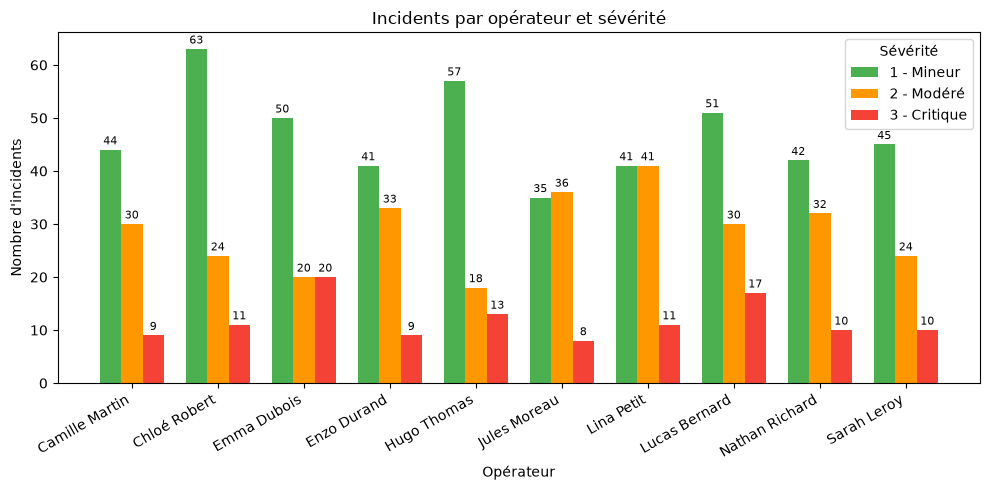

In [10]:
import matplotlib.pyplot as plt
import numpy as np

pivot = df.groupby(["operator_name", "severity"]).size().unstack(fill_value=0)
pivot = pivot.reindex(columns=[1, 2, 3], fill_value=0)

operators = pivot.index.tolist()
x = np.arange(len(operators))
width = 0.25
colors = ["#4caf50", "#ff9800", "#f44336"]
labels = ["1 - Mineur", "2 - Modéré", "3 - Critique"]

fig, ax = plt.subplots(figsize=(10, 5))
for i, (sev, color, label) in enumerate(zip([1, 2, 3], colors, labels)):
    bars = ax.bar(x + (i - 1) * width, pivot[sev], width, label=label, color=color)
    ax.bar_label(bars, padding=2, fontsize=8)

ax.set_xticks(x)
ax.set_xticklabels(operators, rotation=30, ha="right")
ax.set_title("Incidents par opérateur et sévérité")
ax.set_xlabel("Opérateur")
ax.set_ylabel("Nombre d'incidents")
ax.legend(title="Sévérité")
plt.tight_layout()
plt.show()

OK, premier test d'un "graphe from csv"